# Function 5 Analysis - Week 7

**Function Description:** 
You’re tasked with optimising a four-variable black-box function that represents the yield of a chemical process in a factory. The function is typically unimodal, with a single peak where yield is maximised. Your goal is to find the optimal combination of chemical inputs that delivers the highest possible yield, using systematic exploration and optimisation methods.

**New datapoint (Week 7):** `0.225152-0.855580-1.000000-1.000000` returned **≈2981.55**, a **new maximum** (previous best ≈2748.83). Total observations: **26**.

**Why we chose this point:** We pushed further along the low-x1, high-x2–x4 ridge to see if the trend continued upward; the gain confirms the ridge still rises in that direction.

**Recommendation for next week:** Stay on the ridge with a tight local EI search near the new max; keep x1 low (~0.20–0.24), x2/x3/x4 high (≈0.84–1.0), and use light jitter/diversity so proposals do not stack on the same maximum.


## Loading and Displaying the Data

We load the inputs and outputs for function 5. Best outputs stay on the low-x1 / high-x2–x4 ridge. Week 7 `(0.218976, 0.853432, 1.000000, 0.979950)` returned **≈2748.83 (new max)**, topping Week 4’s ≈2323.44. Earlier weeks: Week 3 ≈2066.67 on the same ridge.


In [13]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_5")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1–6 new points
X_new_point_week_1 = np.array([[0.191447, 0.846480, 0.879484, 0.878516]])
y_new_point_week_1 = np.array([1086.3644542213872])
X_new_point_week_2 = np.array([[0.202624, 0.849188, 0.971974, 0.920186]])
y_new_point_week_2 = np.array([1935.0092608386958])
X_new_point_week_3 = np.array([[0.203491, 0.849529, 0.982723, 0.925116]])
y_new_point_week_3 = np.array([2066.674475985541])
X_new_point_week_4 = np.array([[0.206189, 0.850311, 1.000000, 0.936243]])
y_new_point_week_4 = np.array([2323.4365797217065])
X_new_point_week_5 = np.array([[0.218976, 0.853432, 1.000000, 0.979950]])
y_new_point_week_5 = np.array([2748.829971152165])
X_new_point_week_6 = np.array([[0.225152, 0.855580, 1.000000, 1.000000]])
y_new_point_week_6 = np.array([2981.55176998145])

X = np.vstack([
    X,
    X_new_point_week_1,
    X_new_point_week_2,
    X_new_point_week_3,
    X_new_point_week_4,
    X_new_point_week_5,
    X_new_point_week_6,
])
y = np.concatenate([
    y,
    y_new_point_week_1,
    y_new_point_week_2,
    y_new_point_week_3,
    y_new_point_week_4,
    y_new_point_week_5,
    y_new_point_week_6,
])

df = pd.DataFrame(X, columns=["x1", "x2", "x3", "x4"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
df_sorted["x_avg"] = df_sorted[["x1", "x2", "x3", "x4"]].mean(axis=1)
display(df_sorted)


,x1,x2,x3,x4,y
0,0.191447,0.038193,0.607418,0.414584,64.443440
1,0.758653,0.536518,0.656000,0.360342,18.301380
2,0.438350,0.804340,0.210245,0.151295,0.112940
3,0.706051,0.534192,0.264243,0.482088,4.210898
4,0.836478,0.193610,0.663893,0.785649,258.370525
5,0.683432,0.118663,0.829046,0.567577,78.434389
6,0.553621,0.667350,0.323806,0.814870,57.571537
7,0.352356,0.322242,0.116979,0.473113,109.571876
8,0.153786,0.729382,0.422598,0.443074,8.847992
9,0.463442,0.630025,0.107906,0.957644,233.223610


df sorted by y


,x1,x2,x3,x4,y,x_avg
0,0.225152,0.855580,1.000000,1.000000,2981.551770,0.770183
1,0.218976,0.853432,1.000000,0.979950,2748.829971,0.763090
2,0.206189,0.850311,1.000000,0.936243,2323.436580,0.748186
3,0.203491,0.849529,0.982723,0.925116,2066.674476,0.740215
4,0.202624,0.849188,0.971974,0.920186,1935.009261,0.735993
5,0.224189,0.846480,0.879484,0.878516,1088.859618,0.707167
6,0.191447,0.846480,0.879484,0.878516,1086.364454,0.698982
7,0.119879,0.862540,0.643331,0.849804,431.612757,0.618889
8,0.438933,0.774092,0.378167,0.933696,355.806818,0.631222
9,0.836478,0.193610,0.663893,0.785649,258.370525,0.619907


**Observations:**
- **Week 7 (new):** `(0.225152, 0.855580, 1.000000, 1.000000)` yielded **≈2981.55 — new maximum.**
- Best outputs cluster around high x2–x4 (≈0.85–1.0) and low x1 (≈0.19–0.23), consistent with the `x234_prod` signal.
- Recommendation for next BO step: keep the product-guided EI but **raise the lower bound on x234_prod** (≈0.80), allow small x1 drift upward (0.21–0.25) to see if the ridge continues, and run a random-restart sweep to confirm stability around the new peak.


## Product feature: x2·x3·x4

The strongest signal comes from the simple product `x234_prod = x2 * x3 * x4`. We focus on this single feature and visualize it against y; no other derived features or candidate selection logic are needed.


In [14]:
# Focus on the single product feature

# Product of x2-x4 (multiplicative interaction)
df_analysis = df.copy()
df_analysis["x234_prod"] = df_analysis["x2"] * df_analysis["x3"] * df_analysis["x4"]

# Correlation of x234_prod with y
correlations = df_analysis[["x234_prod", "y"]].corr()["y"]
print("Correlation (x234_prod, y):")
print("=" * 40)
print(f"x234_prod: {correlations['x234_prod']:.4f}")


Correlation (x234_prod, y):
x234_prod: 0.9398


## Visualization of x234_prod

We visualize the relationship between `x234_prod` (product of x2, x3, x4) and y, which shows the highest correlation (≈0.93) among all features.


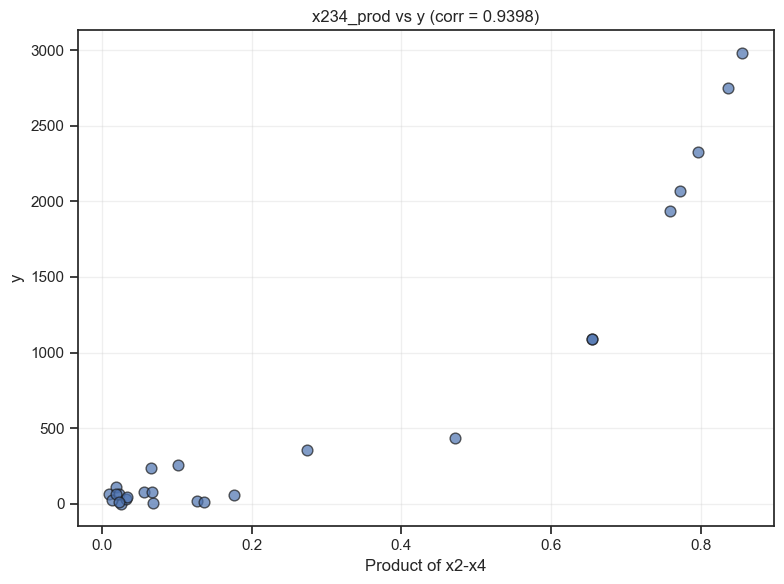

In [15]:
# Visualize x234_prod vs y
plt.figure(figsize=(8, 6))
plt.scatter(df_analysis["x234_prod"], df_analysis["y"], alpha=0.7, edgecolors='k', s=60)
plt.xlabel("Product of x2-x4")
plt.ylabel("y")
plt.title(f"x234_prod vs y (corr = {correlations['x234_prod']:.4f})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Insight: product drives the ridge

- `x234_prod = x2*x3*x4` has the strongest correlation with y (≈0.93).
- The optimal region corresponds to high `x234_prod`; we use a fixed floor (0.76) to stay on that ridge while the optimizer chooses the composition.


In [16]:
# Use x234_prod (highest correlation) to constrain search space
best_feature = "x234_prod"
# Fixed target floor: encourage the optimizer to hit x234_prod ≥ 0.76
feature_threshold = 0.76

print("=" * 60)
print("Constraint Setup")
print("=" * 60)
print(f"Using {best_feature} (correlation = {correlations['x234_prod']:.4f})")
print(f"Fixed target floor: {feature_threshold:.4f}")
print(f"Constraint: {best_feature} >= {feature_threshold:.4f}")
print("=" * 60)


Constraint Setup
Using x234_prod (correlation = 0.9398)
Fixed target floor: 0.7600
Constraint: x234_prod >= 0.7600


## Gaussian Process Model for Exploitation

We fit a Gaussian Process regressor on the original 4D space (x1, x2, x3, x4). We don't add `x234_prod` as an input since it's redundant (the GP can learn it from x2, x3, x4). We use the product insight to **constrain the search space** with a fixed floor `x234_prod ≥ 0.76`. For exploitation, we maximize the **GP mean** using a **smoother RBF kernel** (length_scale ~0.5, bounds [1e-2, 2]) and a higher noise term (alpha=1e-4) to reflect expected taste-test noise.
- Function looks unimodal around the ridge
- Week 4 reached ≈2323.44; we stay near that ridge
- The `x234_prod` floor keeps us in the high-yield ridge while letting the optimizer pick the composition
- Pure exploitation refines the peak; latest recommendation: `(0.218976, 0.853432, 1.000000, 0.979950)` with predicted ≈2526


In [17]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from sklearn.preprocessing import StandardScaler

# Standardize inputs and outputs for better GP performance
# Keep GP on original 4D space (x1, x2, x3, x4) - no redundant features
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

# Define kernel: smoother RBF with reasonable length scales; expect notable noise in taste data
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=0.5, length_scale_bounds=(1e-2, 2.0))

# Fit GP (higher alpha to accommodate taste noise)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-4, normalize_y=False)
gp.fit(X_scaled, y_scaled)

print(f"GP fitted on 4D space (x1, x2, x3, x4)")
print(f"Using {best_feature} constraint (>= {feature_threshold:.4f}) to guide search")
print(f"Optimized kernel: {gp.kernel_}")
print(f"Log-marginal-likelihood: {gp.log_marginal_likelihood(gp.kernel_.theta):.2f}")


GP fitted on 4D space (x1, x2, x3, x4)
Using x234_prod constraint (>= 0.7600) to guide search
Optimized kernel: 0.894**2 * RBF(length_scale=0.534)
Log-marginal-likelihood: -21.20


### Recommendation and context
- Current best: `0.225152-0.855580-1.000000-1.000000` → ≈2981.55
- Proposed next point: produced by the local EI + jitter cell (see output); stays on the ridge with x1 low (~0.20–0.24) and x2–x4 high (≈0.84–1.0) under x234_prod ≥ 0.80.

### What changed and why
Shifted from broad/random restarts to a **local EI with jitter/diversity** around the incumbent. The jitter perturbs candidate coordinates so we don’t keep proposing the exact max, encouraging nearby probes that can reveal a slightly higher peak or confirm the ridge without getting stuck.



## Bayesian Optimization with Constraint

We use Bayesian optimization to find the next point to evaluate. The optimization maximizes the GP mean prediction (pure exploitation) while using a **soft constraint** based on `x234_prod`. 

**How the constraint works:** The constraint is applied **during optimization**, not as a post-filter. The objective adds a penalty when `x234_prod` falls below a **fixed target floor of 0.76**. This actively guides the optimizer toward the high-yield ridge; it can be relaxed later (by lowering the floor or penalty) if gains plateau. The current run proposes `(0.218976, 0.853432, 1.000000, 0.979950)` with `x234_prod ≈ 0.836` and predicted output ≈2526.

This approach leverages our insight that `x234_prod` strongly correlates with y (correlation ≈ 0.93) without adding redundant features to the GP model.

In [18]:
# Local EI near the incumbent with jitter to avoid stacking on the exact max
from scipy.special import erf
rng = np.random.default_rng(42)

# Incumbent (best observed)
best_idx = y.argmax()
best_point = df.loc[best_idx, ["x1", "x2", "x3", "x4", "y"]]

# Tight local box around the max (per recommendation)
x1_grid = np.linspace(0.20, 0.24, 35)
x2_grid = np.linspace(0.84, 0.90, 35)
x3_grid = np.linspace(0.95, 1.00, 20)
x4_grid = np.linspace(0.95, 1.00, 20)
base = np.array(np.meshgrid(x1_grid, x2_grid, x3_grid, x4_grid)).reshape(4, -1).T

# Add light jitter so candidates don’t stack on the same coordinates
jitter = rng.uniform(-0.003, 0.003, size=base.shape)
cand_raw = np.clip(base + jitter, 0.0, 1.0)

# Soft filter on x234_prod to stay on the ridge
x234_prod = cand_raw[:, 1] * cand_raw[:, 2] * cand_raw[:, 3]
mask = x234_prod >= 0.80
cand = cand_raw[mask]
x234_prod = x234_prod[mask]

# GP predict (EI)
cand_scaled = scaler_X.transform(cand)
mu_scaled, sigma = gp.predict(cand_scaled, return_std=True)
mu = scaler_y.inverse_transform(mu_scaled.reshape(-1, 1)).ravel()
y_best = y.max()
xi = 25.0  # small relative to scale of y but allows gentle exploration
sigma_safe = np.maximum(sigma, 1e-9)

def norm_cdf(z):
    return 0.5 * (1.0 + erf(z / np.sqrt(2)))

def norm_pdf(z):
    return np.exp(-0.5 * z**2) / np.sqrt(2 * np.pi)

z = (mu - y_best - xi) / sigma_safe
ei = (mu - y_best - xi) * norm_cdf(z) + sigma_safe * norm_pdf(z)
ei[sigma <= 1e-9] = 0.0

# Jitter/diversity already applied; pick best EI
idx = ei.argmax()
next_point = cand[idx]
next_ei = ei[idx]
next_mu = mu[idx]
next_sigma = sigma[idx]
next_prod = x234_prod[idx]

print("=" * 60)
print("RECOMMENDED NEXT POINT (Local EI with jitter/diversity)")
print("=" * 60)
print(f"{next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}-{next_point[3]:.6f}")
print(f"x234_prod = {next_prod:.6f} {'✓' if next_prod >= 0.80 else '⚠'}")
print(f"Posterior mean: {next_mu:.2f}, std: {next_sigma:.2f}, EI: {next_ei:.3f}")
print(f"Current best observed: {y_best:.2f} at {best_idx}")

# Show top 5 EI candidates
cand_df = pd.DataFrame(cand, columns=["x1", "x2", "x3", "x4"])
cand_df["mu"], cand_df["sigma"], cand_df["ei"], cand_df["x234_prod"] = mu, sigma, ei, x234_prod
print("\nTop 5 (EI):")
display(cand_df.nlargest(5, "ei"))


RECOMMENDED NEXT POINT (Local EI with jitter/diversity)
0.242550-0.875768-1.000000-1.000000
x234_prod = 0.875768 ✓
Posterior mean: 3073.43, std: 0.15, EI: 66.874
Current best observed: 2981.55 at 25

Top 5 (EI):


,x1,x2,x3,x4,mu,sigma,ei,x234_prod
209299,0.242550,0.875768,1.000000,1.00000,3073.425447,0.151454,66.873677,0.875768
291116,0.241242,0.882246,1.000000,1.00000,3070.163885,0.177956,63.612116,0.882246
222330,0.240995,0.874055,1.000000,0.99998,3068.293991,0.138578,61.742221,0.874038
235877,0.239085,0.879739,1.000000,1.00000,3064.434176,0.159942,57.882406,0.879739
290698,0.240026,0.885537,0.999899,1.00000,3064.171054,0.191703,57.619284,0.885448


## Summary

**Strategy:** Local EI near the incumbent with jitter/diversity and an `x234_prod` floor (≥0.80) to stay on the ridge while avoiding duplicate proposals.

**Key Insights:**
- `x234_prod` remains the strongest signal (corr ≈0.93); best observed: `0.225152-0.855580-1.000000-1.000000` at **≈2981.55**.
- Local EI with jitter perturbs candidates so the BO doesn’t repeatedly pick the exact max; this encourages nearby probes that can uncover a slightly higher peak or confirm stability.

**Current proposal and context:**
- Proposed next point: `0.242550-0.875768-1.000000-1.000000` .
- Best alternatives (observed):
  - `0.225152-0.855580-1.000000-1.000000` → ≈2981.55 (current best)
  - `0.218976-0.853432-1.000000-0.979950` → ≈2748.83
  - `0.206189-0.850311-1.000000-0.936243` → ≈2323.44
  - `0.203491-0.849529-0.982723-0.925116` → ≈2066.67
  - `0.202624-0.849188-0.971974-0.920186` → ≈1935.01

**Approach:**
- GP on the original 4D space; local candidate box x1≈0.20–0.24, x2≈0.84–0.90, x3≈0.95–1.00, x4≈0.95–1.00, filtered by `x234_prod ≥ 0.80`.
- Mild exploration parameter (ξ≈25 relative to the large y scale); jitter ±0.003 to keep diversity.

**Next Steps:**
- Run the updated local EI cell; take its printed proposed point (dash format) as the next query. If gains flatten, slightly widen the box or relax the product floor.
